# False positive and detection rates of recombinant detection vs k

The paper chooses $k = 4$ on qualitative grounds: $k = 3$ gave "many dubious
recombination events", $k = 5$ "failed to include the well supported recombination
events documented in" Jackson et al. Those are a false positive claim and a false
negative claim. This quantifies both.

Synthetic single-breakpoint recombinants are spliced from pairs of real UK sequences
collected on 2021-05-16, and matched against the raw inference ARG for 2021-05-15 with
`sc2ts run-hmm`. Real sequences held out of the parent pool act as non-recombinant
controls, so a control matched to more than one parent is a false positive.

Two crosses bracket the range of parent divergence seen in the real ARG. Alpha x Alpha
parents sit at pangonet distance 0, like the 31% of real recombinants whose parents
share a lineage; Alpha x Delta sit at 4-5, against a real median of 2.

Each parent is also given random mutations before splicing, to model parents that were
not themselves sampled: none (0x), the number expected in one transmission generation
(1x, as if every case were sequenced), or five times that (5x, one case in five).
Controls get the same. The sections up to "Unsampled parents" use the 0x arm alone.

See `simulations/synthetic_recombinants/` for the workflow.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats

In [2]:
results_dir = Path("../simulations/synthetic_recombinants")
df_all = pd.read_csv(results_dir / "results.csv")
# Only recombinants matched with two parents have these, so they arrive as
# object columns with blanks.
for column in ["breakpoint_in_interval", "net_min_supporting_loci_lft_rgt_ge_4"]:
    df_all[column] = df_all[column].astype("boolean")

# How many sites separate the parents on the sparser side of the true breakpoint.
# This is the signal available to the HMM, known by construction.
df_all["min_informative"] = np.minimum(
    df_all.num_informative_left, df_all.num_informative_right
)
multipliers = sorted(df_all.mutation_multiplier.unique())

# Parents and controls exactly as sampled.
df = df_all[df_all.mutation_multiplier == 0]

recombinants = df[df.type == "recombinant"]
controls = df[df.type == "control"]
k_values = sorted(df.k.unique())
crosses = list(recombinants.cross.unique())
len(df), k_values, crosses

(225, [np.int64(3), np.int64(4), np.int64(5)], ['AlphaxAlpha', 'AlphaxDelta'])

In [3]:
# k is ordered, so one hue stepped light to dark. Crosses are unordered, so two
# distinct hues.
k_colors = dict(zip(k_values, ["#86b6ef", "#2a78d6", "#104281"]))
cross_colors = dict(zip(crosses, ["#2a78d6", "#eb6834"]))
# Controls are the reference class, not a third category, so they take neutral
# ink rather than a hue of their own.
control_color = "#52514e"
grid_kwargs = dict(color="0.9", linewidth=0.6)

# The paper's own thresholds, for reference throughout.
QC_COLUMN = "net_min_supporting_loci_lft_rgt_ge_4"
QC_CUTOFF = 4
HMM_COST_THRESHOLD = 7
PAPER_MEDIAN_INTERVAL = 2018


def clean_axes(ax):
    ax.yaxis.grid(True, **grid_kwargs)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

## False positives

Controls are real, non-recombinant sequences. Any matched to more than one parent is a
false positive. `fp_upper_95` is the one-sided Clopper-Pearson upper bound, which is
what the number of controls actually buys.

In [4]:
rows = []
for k in k_values:
    ctl = controls[controls.k == k]
    n_fp = int(ctl.detected.sum())
    rows.append(
        {
            "k": k,
            "n_controls": len(ctl),
            "false_positives": n_fp,
            "fp_rate": n_fp / len(ctl),
            "fp_upper_95": scipy.stats.beta.ppf(0.95, n_fp + 1, len(ctl) - n_fp),
            "fp_passing_qc": int(ctl[QC_COLUMN].fillna(False).sum()),
            "median_cost": ctl.hmm_cost.median(),
        }
    )
false_positives = pd.DataFrame(rows).set_index("k")
false_positives.round(3)

,n_controls,false_positives,fp_rate,fp_upper_95,fp_passing_qc,median_cost
k,,,,,,
3,25,0,0.0,0.113,0,0.0
4,25,0,0.0,0.113,0,0.0
5,25,0,0.0,0.113,0,0.0


## Detection

`detection_rate` is unconditional. `qc_pass_rate` is the fraction of *detected*
recombinants that clear the paper's QC gate of at least 4 net supporting loci on both
flanks — the filter that leaves 647 of 1,319 real events. `breakpoint_in_interval` is
how often the true breakpoint falls inside the inferred interval.

In [5]:
rows = []
for (cross, k), group in recombinants.groupby(["cross", "k"]):
    detected = group[group.detected]
    rows.append(
        {
            "cross": cross,
            "k": k,
            "n": len(group),
            "detection_rate": group.detected.mean(),
            "qc_pass_rate": detected[QC_COLUMN].mean(),
            "breakpoint_in_interval": detected.breakpoint_in_interval.mean(),
            "median_interval_width": detected.interval_width.median(),
            "median_net_loci": np.minimum(
                detected.net_min_supporting_loci_lft,
                detected.net_min_supporting_loci_rgt,
            ).median(),
            "median_cost": group.hmm_cost.median(),
            "parent_distance": group.parent_pangonet_distance.median(),
        }
    )
detection = pd.DataFrame(rows).set_index(["cross", "k"])
detection.round(3)

n  detection_rate  qc_pass_rate  breakpoint_in_interval  \
cross       k                                                             
AlphaxAlpha 3  25            0.76         0.737                     1.0   
            4  25            0.52         0.923                     1.0   
            5  25            0.20         1.000                     1.0   
AlphaxDelta 3  25            0.96         1.000                     1.0   
            4  25            0.96         1.000                     1.0   
            5  25            0.92         1.000                     1.0   

               median_interval_width  median_net_loci  median_cost  \
cross       k                                                        
AlphaxAlpha 3                 6094.0              4.0          3.0   
            4                 4021.0              4.0          4.0   
            5                 4021.0              6.0          4.0   
AlphaxDelta 3                 1117.5             18.0          3.0   
            4                 1117.5             18.0          4.0   
            5                 1064.0             19.0          5.0   

               parent_distance  
cross       k                   
AlphaxAlpha 3              0.0  
            4              0.0  
            5              0.0  
AlphaxDelta 3              5.0  
            4              5.0  
            5              5.0

## Why recombinants are missed

Detection needs the sparser flank to carry more mismatches than the recombination
penalty $k$, otherwise a single-parent match plus a few mutations is the cheaper
explanation. Breakpoints leaving a flank with no distinguishing sites at all are
excluded by construction, so every recombinant here is detectable in principle.

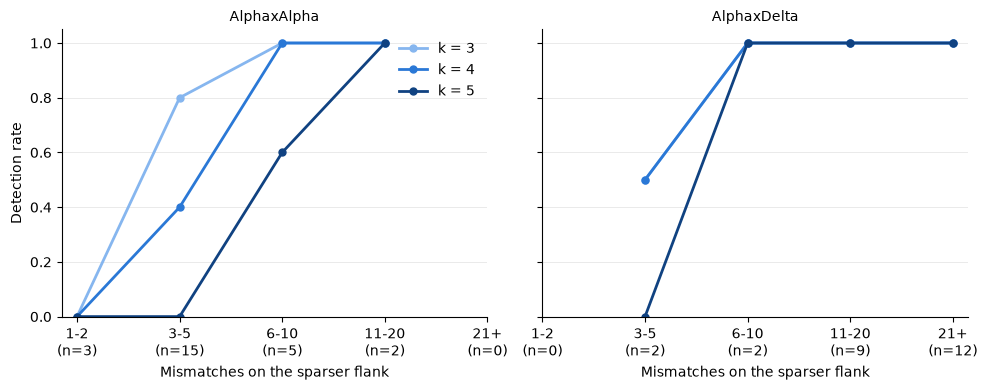

In [6]:
bins = [0, 2, 5, 10, 20, np.inf]
labels = ["1-2", "3-5", "6-10", "11-20", "21+"]

fig, axes = plt.subplots(1, len(crosses), figsize=(10, 4), sharey=True)
for ax, cross in zip(axes, crosses):
    subset = recombinants[recombinants.cross == cross]
    for k in k_values:
        group = subset[subset.k == k].copy()
        group["bin"] = pd.cut(group.min_informative, bins=bins, labels=labels)
        rate = group.groupby("bin", observed=False).detected.mean()
        ax.plot(
            range(len(labels)),
            rate.values,
            marker="o",
            markersize=5,
            linewidth=2,
            color=k_colors[k],
            label=f"k = {k}",
        )
    counts = (
        pd.cut(
            subset[subset.k == k_values[0]].min_informative, bins=bins, labels=labels
        )
        .value_counts()
        .reindex(labels)
    )
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels([f"{label}\n(n={n})" for label, n in counts.items()])
    ax.set_title(cross, fontsize=10)
    ax.set_xlabel("Mismatches on the sparser flank")
    ax.set_ylim(0, 1.05)
    clean_axes(ax)
axes[0].set_ylabel("Detection rate")
axes[0].legend(frameon=False)
fig.tight_layout()

## Net supporting loci

The paper's QC measure, computed the same way: sites where the two inferred parents
differ, clustered into loci when within 3 bases, scored +1 where the recombinant
carries the assigned parent's allele and -1 where it carries the other's. The shaded
region is the failing one, fewer than 4 net loci on either flank.

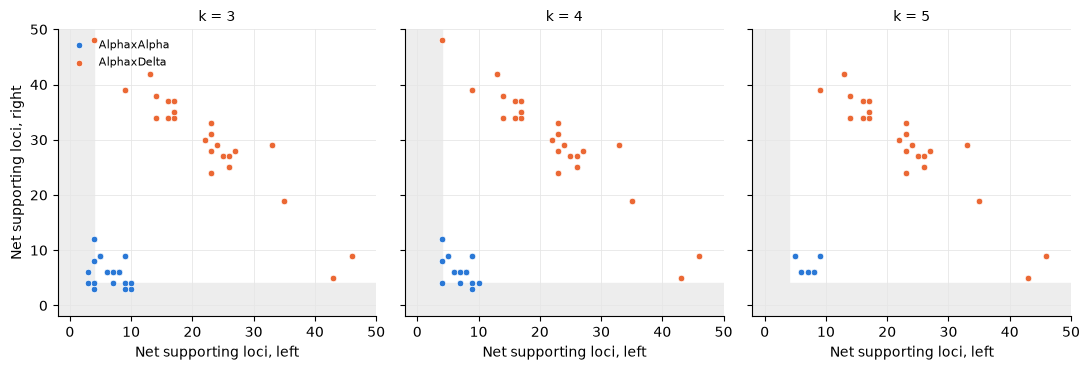

In [7]:
fig, axes = plt.subplots(1, len(k_values), figsize=(11, 3.8), sharex=True, sharey=True)
detected = df[df.detected]
limit = max(detected.net_min_supporting_loci_lft.max(),
            detected.net_min_supporting_loci_rgt.max()) + 2
for ax, k in zip(axes, k_values):
    ax.axhspan(-limit, QC_CUTOFF, color="0.93", zorder=0)
    ax.axvspan(-limit, QC_CUTOFF, color="0.93", zorder=0)
    for cross in crosses:
        subset = detected[(detected.k == k) & (detected.cross == cross)]
        ax.scatter(
            subset.net_min_supporting_loci_lft,
            subset.net_min_supporting_loci_rgt,
            s=22,
            color=cross_colors[cross],
            edgecolor="white",
            linewidth=0.5,
            label=cross,
            zorder=3,
        )
    false_positives_k = detected[(detected.k == k) & (detected.type == "control")]
    if len(false_positives_k) > 0:
        ax.scatter(
            false_positives_k.net_min_supporting_loci_lft,
            false_positives_k.net_min_supporting_loci_rgt,
            s=40,
            marker="X",
            color="#e34948",
            edgecolor="white",
            linewidth=0.5,
            label="false positive",
            zorder=4,
        )
    ax.set_title(f"k = {k}", fontsize=10)
    ax.set_xlabel("Net supporting loci, left")
    ax.set_xlim(-2, limit)
    ax.set_ylim(-2, limit)
    clean_axes(ax)
    ax.xaxis.grid(True, **grid_kwargs)
axes[0].set_ylabel("Net supporting loci, right")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()

## Breakpoint intervals

The interval is the region between the last site supporting the left parent and the
first supporting the right, computed by `sc2ts.inference.characterise_recombinants`,
the same function the inference pipeline calls.

The paper reports a median interval of 2,018 bases for the real ARG (dashed line), and
a negative relationship between interval width and the divergence between the parents.
The two crosses reproduce that relationship and bracket the real median: Alpha x Alpha,
whose parents sit at pangonet distance 0, gives much wider intervals than Alpha x Delta
at distance 4-5. Closer parents leave fewer sites to pin the breakpoint against.

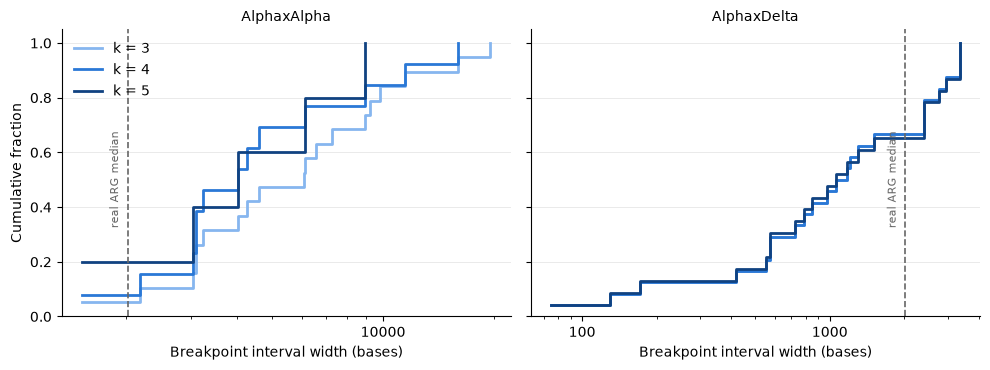

In [8]:
fig, axes = plt.subplots(1, len(crosses), figsize=(10, 3.8), sharey=True)
for ax, cross in zip(axes, crosses):
    subset = detected[(detected.cross == cross) & (detected.type == "recombinant")]
    for k in k_values:
        width = np.sort(subset[subset.k == k].interval_width.values)
        if len(width) == 0:
            continue
        ax.step(
            width,
            np.arange(1, len(width) + 1) / len(width),
            where="post",
            linewidth=2,
            color=k_colors[k],
            label=f"k = {k}",
        )
    ax.axvline(PAPER_MEDIAN_INTERVAL, color="0.4", linestyle="--", linewidth=1.2)
    ax.annotate(
        "real ARG median",
        xy=(PAPER_MEDIAN_INTERVAL, 0.5),
        xytext=(-5, 0),
        textcoords="offset points",
        rotation=90,
        ha="right",
        va="center",
        fontsize=8,
        color="0.4",
    )
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_title(cross, fontsize=10)
    ax.set_xlabel("Breakpoint interval width (bases)")
    ax.set_ylim(0, 1.05)
    clean_axes(ax)
axes[0].set_ylabel("Cumulative fraction")
axes[0].legend(frameon=False, loc="upper left")
fig.tight_layout()

In [9]:
quartiles = (
    detected[detected.type == "recombinant"]
    .groupby(["cross", "k"])
    .interval_width.describe()[["min", "25%", "50%", "75%", "max"]]
)
quartiles.round(0)

min     25%     50%     75%      max
cross       k                                         
AlphaxAlpha 3  1516.0  3164.0  6094.0  9083.0  19605.0
            4  1516.0  3097.0  4021.0  6117.0  16005.0
            5  1516.0  3042.0  4021.0  6117.0   8934.0
AlphaxDelta 3    75.0   573.0  1118.0  2397.0   3343.0
            4    75.0   573.0  1118.0  2397.0   3343.0
            5    75.0   573.0  1064.0  2397.0   3343.0

## HMM cost

A single-parent match pays no recombination penalty, so control costs do not vary with
$k$. Recombinant cost sits at $k$ plus any extra mutations, which pushes some genuine
recombinants past the `hmm_cost_threshold = 7` used in the real inference, regardless
of whether the recombination itself was found.

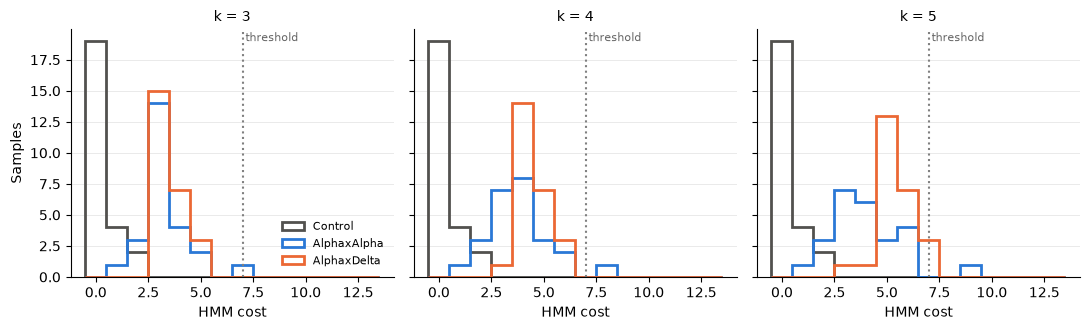

In [10]:
fig, axes = plt.subplots(1, len(k_values), figsize=(11, 3.4), sharey=True)
edges = np.arange(-0.5, 14)
for ax, k in zip(axes, k_values):
    series = [("Control", controls[controls.k == k].hmm_cost, control_color)]
    series += [
        (cross, recombinants[(recombinants.k == k) & (recombinants.cross == cross)].hmm_cost,
         cross_colors[cross])
        for cross in crosses
    ]
    for label, data, color in series:
        ax.hist(data, bins=edges, histtype="step", linewidth=2, color=color, label=label)
    ax.axvline(HMM_COST_THRESHOLD, color="0.5", linestyle=":", linewidth=1.5)
    ax.annotate(
        "threshold",
        xy=(HMM_COST_THRESHOLD, ax.get_ylim()[1]),
        xytext=(2, -2),
        textcoords="offset points",
        va="top",
        fontsize=8,
        color="0.4",
    )
    ax.set_title(f"k = {k}", fontsize=10)
    ax.set_xlabel("HMM cost")
    clean_axes(ax)
axes[0].set_ylabel("Samples")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()

In [11]:
above_threshold = (
    df.assign(above=df.hmm_cost > HMM_COST_THRESHOLD)
    .groupby(["type", "cross", "k"], dropna=False)
    .above.mean()
    .unstack("k")
)
above_threshold.round(3)

k                          3     4     5
type        cross                       
control     NaN          0.0  0.00  0.00
recombinant AlphaxAlpha  0.0  0.04  0.04
            AlphaxDelta  0.0  0.00  0.00

## Unsampled parents

Every arm has the same parent pairs, breakpoints and controls, so differences between
arms are due to the added mutations alone. `detection_rate` is the fraction matched to
more than one parent, which for controls is the false positive rate; `qc_pass_rate` is
the fraction of those that clear the QC gate. `above_cost_threshold` is the fraction
whose HMM cost exceeds the `hmm_cost_threshold = 7` used in the real inference.

In [12]:
by_arm = df_all.assign(group=df_all.cross.fillna("control"))
groups = ["control"] + crosses
rows = []
for (group_name, m, k), group in by_arm.groupby(["group", "mutation_multiplier", "k"]):
    detected_group = group[group.detected]
    rows.append(
        {
            "group": group_name,
            "multiplier": m,
            "k": k,
            "n": len(group),
            "mean_added_mutations": group.num_added_mutations.mean(),
            "detection_rate": group.detected.mean(),
            "qc_pass_rate": detected_group[QC_COLUMN].mean(),
            "breakpoint_in_interval": detected_group.breakpoint_in_interval.mean(),
            "median_interval_width": detected_group.interval_width.median(),
            "median_cost": group.hmm_cost.median(),
            "above_cost_threshold": (group.hmm_cost > HMM_COST_THRESHOLD).mean(),
        }
    )
by_multiplier = pd.DataFrame(rows).set_index(["group", "multiplier", "k"])
by_multiplier.loc[groups].round(3)

n  mean_added_mutations  detection_rate  \
group       multiplier k                                             
control     0          3  25                  0.00            0.00   
                       4  25                  0.00            0.00   
                       5  25                  0.00            0.00   
            1          3  25                  0.36            0.00   
                       4  25                  0.36            0.00   
                       5  25                  0.36            0.00   
            5          3  25                  2.04            0.00   
                       4  25                  2.04            0.00   
                       5  25                  2.04            0.00   
AlphaxAlpha 0          3  25                  0.00            0.76   
                       4  25                  0.00            0.52   
                       5  25                  0.00            0.20   
            1          3  25                  0.52            0.76   
                       4  25                  0.52            0.52   
                       5  25                  0.52            0.20   
            5          3  25                  1.64            0.76   
                       4  25                  1.64            0.56   
                       5  25                  1.64            0.20   
AlphaxDelta 0          3  25                  0.00            0.96   
                       4  25                  0.00            0.96   
                       5  25                  0.00            0.92   
            1          3  25                  0.32            0.96   
                       4  25                  0.32            0.96   
                       5  25                  0.32            0.92   
            5          3  25                  2.04            0.96   
                       4  25                  2.04            0.96   
                       5  25                  2.04            0.92   

                         qc_pass_rate breakpoint_in_interval  \
group       multiplier k                                       
control     0          3         <NA>                   <NA>   
                       4         <NA>                   <NA>   
                       5         <NA>                   <NA>   
            1          3         <NA>                   <NA>   
                       4         <NA>                   <NA>   
                       5         <NA>                   <NA>   
            5          3         <NA>                   <NA>   
                       4         <NA>                   <NA>   
                       5         <NA>                   <NA>   
AlphaxAlpha 0          3     0.736842                    1.0   
                       4     0.923077                    1.0   
                       5          1.0                    1.0   
            1          3     0.736842                    1.0   
                       4     0.923077                    1.0   
                       5          1.0                    1.0   
            5          3     0.789474               0.947368   
                       4     0.928571               0.928571   
                       5          1.0                    1.0   
AlphaxDelta 0          3          1.0                    1.0   
                       4          1.0                    1.0   
                       5          1.0                    1.0   
            1          3          1.0                    1.0   
                       4          1.0                    1.0   
                       5          1.0                    1.0   
            5          3          1.0                    1.0   
                       4          1.0                    1.0   
                       5          1.0                    1.0   

                          median_interval_width  median_cost  \
group       multiplier k                                       
control    

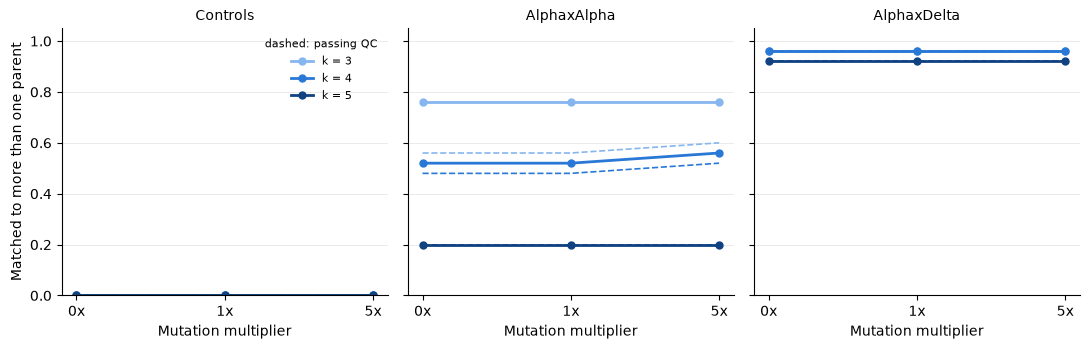

In [13]:
fig, axes = plt.subplots(1, len(groups), figsize=(11, 3.6), sharey=True)
for ax, group_name in zip(axes, groups):
    for k in k_values:
        rates = by_multiplier.loc[(group_name, slice(None), k)]
        ax.plot(
            range(len(multipliers)),
            rates.detection_rate.values,
            marker="o",
            markersize=5,
            linewidth=2,
            color=k_colors[k],
            label=f"k = {k}",
        )
        # Detected and passing the QC gate.
        ax.plot(
            range(len(multipliers)),
            (rates.detection_rate * rates.qc_pass_rate.fillna(0)).values,
            linestyle="--",
            linewidth=1.2,
            color=k_colors[k],
        )
    ax.set_xticks(range(len(multipliers)))
    ax.set_xticklabels([f"{m}x" for m in multipliers])
    ax.set_title(group_name if group_name != "control" else "Controls", fontsize=10)
    ax.set_xlabel("Mutation multiplier")
    ax.set_ylim(0, 1.05)
    clean_axes(ax)
axes[0].set_ylabel("Matched to more than one parent")
axes[0].legend(frameon=False, title="dashed: passing QC", title_fontsize=8, fontsize=8)
fig.tight_layout()

## Caveats

- Breakpoints are drawn uniformly over the window in which they are detectable at all,
  rather than over the genome. Recombinants whose breakpoint leaves one flank identical
  to both parents are excluded by construction, since no value of $k$ could recover
  them. `detectable_window` records the span that was sampled.
- Parents are contemporaneous sequences from a single day, so the divergence between
  them is fixed by the choice of cross rather than drawn from the pandemic. Breakpoint
  interval widths are therefore not directly comparable to the real ARG's.
- Added mutations are uniform over the genome, with no mutational spectrum or rate
  variation.
- Controls bound the false positive rate from above; they cannot establish that it is
  zero.